In [1]:
import numpy as np
import matplotlib.pyplot as plt

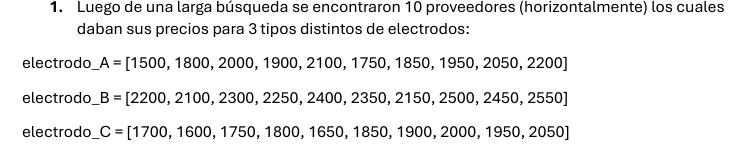

In [2]:
elec_A = [1500, 1800, 2000, 1900, 2100, 1750, 1850, 1950, 2050, 2200]
elec_B = [2200, 2100, 2300, 2250, 2400, 2350, 2150, 2500, 2450, 2550]
elec_C = [1700, 1600, 1750, 1800, 1650, 1850, 1900, 2000, 1950, 2050]

In [3]:
def estad(vect,nomb):
  prom=np.mean(vect)
  vmax=np.max(vect)
  vmin=np.min(vect)
  print(f"""El precio promedio del ELECTRODO {nomb}: ${prom}
  Rango de precios de los proveedores del ELECTRODO {nomb}: ${vmax}-${vmin}""")


In [4]:
estad(elec_A,"A")
estad(elec_B,"B")
estad(elec_C,"C")

El precio promedio del ELECTRODO A: $1910.0
  Rango de precios de los proveedores del ELECTRODO A: $2200-$1500
El precio promedio del ELECTRODO B: $2325.0
  Rango de precios de los proveedores del ELECTRODO B: $2550-$2100
El precio promedio del ELECTRODO C: $1825.0
  Rango de precios de los proveedores del ELECTRODO C: $2050-$1600


In [5]:
A=np.array(elec_A)
B=np.array(elec_B)
C=np.array(elec_C)
Mat=np.vstack((A,B,C))
print(Mat)

[[1500 1800 2000 1900 2100 1750 1850 1950 2050 2200]
 [2200 2100 2300 2250 2400 2350 2150 2500 2450 2550]
 [1700 1600 1750 1800 1650 1850 1900 2000 1950 2050]]


In [6]:
imp=(Mat[0,:]*0.1)+Mat[0,:]
Mat[0,:]=imp
print(Mat)

[[1650 1980 2200 2090 2310 1925 2035 2145 2255 2420]
 [2200 2100 2300 2250 2400 2350 2150 2500 2450 2550]
 [1700 1600 1750 1800 1650 1850 1900 2000 1950 2050]]


In [7]:
Mmin=np.min(Mat, axis=1)
prov=np.argmin(Mat, axis=1)
for i in range(len(Mmin)):
  nomb_=["A","B","C"]
  print(f"El Proveedor más económico del electrodo {nomb_[i]} es: Proveedor #{prov[i]+1}.")


El Proveedor más económico del electrodo A es: Proveedor #1.
El Proveedor más económico del electrodo B es: Proveedor #2.
El Proveedor más económico del electrodo C es: Proveedor #2.


In [8]:
Mprom=np.round(np.mean(Mat, axis=0))
print(Mprom)
prove = np.where(Mprom < 2000)[0] + 1
print("Los proveedores con promedios de precio < 2000 son", prove)


[1850. 1893. 2083. 2047. 2120. 2042. 2028. 2215. 2218. 2340.]
Los proveedores con promedios de precio < 2000 son [1 2]


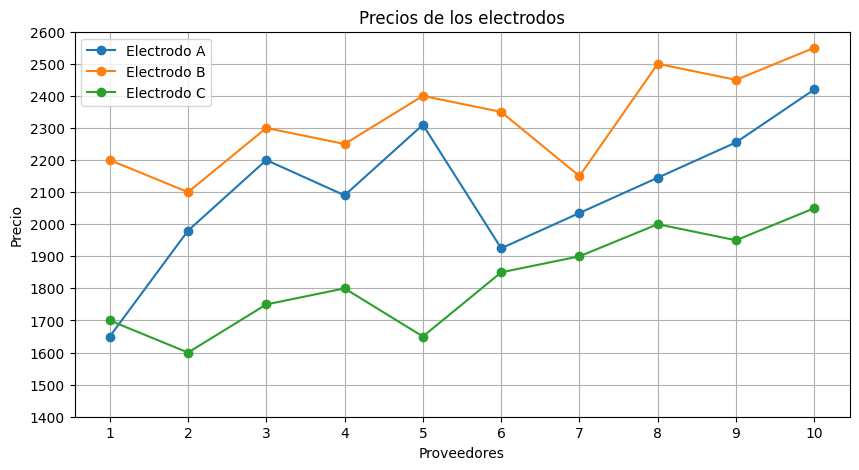

In [9]:
plt.figure(figsize=(10,5))
plt.plot(Mat[0,:],marker="o", label="Electrodo A")
plt.plot(Mat[1,:],marker="o", label="Electrodo B")
plt.plot(Mat[2,:],marker="o", label="Electrodo C")
plt.legend()
plt.xticks(range(10),range(1,11))
plt.yticks(range(1400,2700,100))
plt.xlabel("Proveedores")
plt.ylabel("Precio")
plt.title("Precios de los electrodos")
plt.grid()
plt.show()

In [10]:
desv=np.std(Mat, axis=1)
electrodo=np.argmax(desv)
print("El electrodo con mayor variabilidad es el Electrodo",nomb_[electrodo])
print("Su desviación estándar es:", round(desv[electrodo],2))

El electrodo con mayor variabilidad es el Electrodo A
Su desviación estándar es: 208.42


## **Segunda Parte**

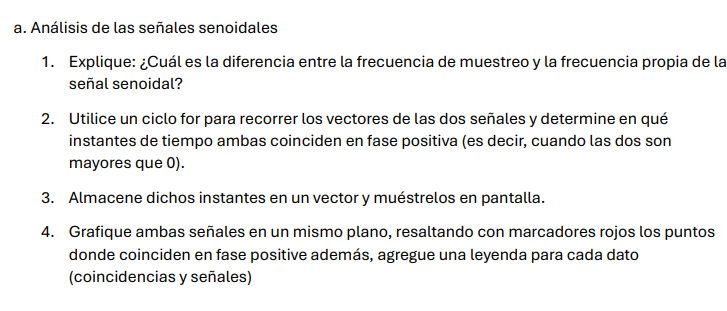

In [11]:
def sin1(tf,Ts):
  t1=np.arange(0, tf+Ts, Ts)
  y1=0.5*np.sin(2*np.pi*t1*1/4)
  return t1 , y1

In [12]:
def sin2(tf,Ts):
  t2=np.arange(0, tf+Ts, Ts)
  y2=2*np.sin(2*np.pi*t2*1/5)
  return t2,y2

In [13]:
A1 = np.random.uniform(-2, 2, 100)
A2 = np.random.uniform(-4, 4, 100)

In [14]:
t1,y1=sin1(20,0.5)
t2,y2=sin2(20,0.5)

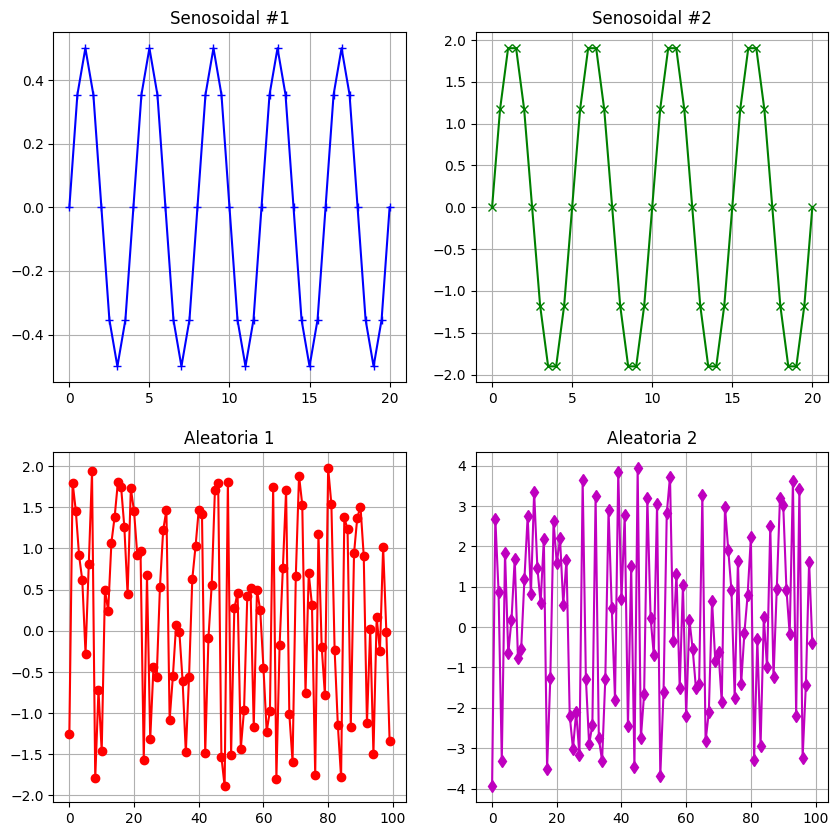

In [15]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.plot(t1,y1,marker="+",color="b")
plt.title("Senosoidal #1")
plt.grid()
plt.subplot(2,2,2)
plt.plot(t2,y2,marker="x",color="g")
plt.title("Senosoidal #2")
plt.grid()
plt.subplot(2,2,3)
plt.plot(A1,marker="o",color="r")
plt.title("Aleatoria 1")
plt.grid()
plt.subplot(2,2,4)
plt.plot(A2,marker="d",color="m")
plt.title("Aleatoria 2")
plt.grid()
plt.show()

### Explique: ¿Cuál es la diferencia entre la frecuencia de muestreo y la frecuencia propia de la señal senoidal?

*Frecuencia de la señal:* Es la frecuencia a la que se repite cada señal.

*Frecuencia de muestreo:* Frecuencia a la que se toman los datos que hacen parte de cada ciclo de la señal.

[ 0.5  1.   1.5  2.   5.5  6.  12.5 16.5 17.  17.5  0.5  1.   1.5  2.
  5.5  6.  12.5 16.5 17.  17.5]


/tmp/ipykernel_9332/3188990229.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


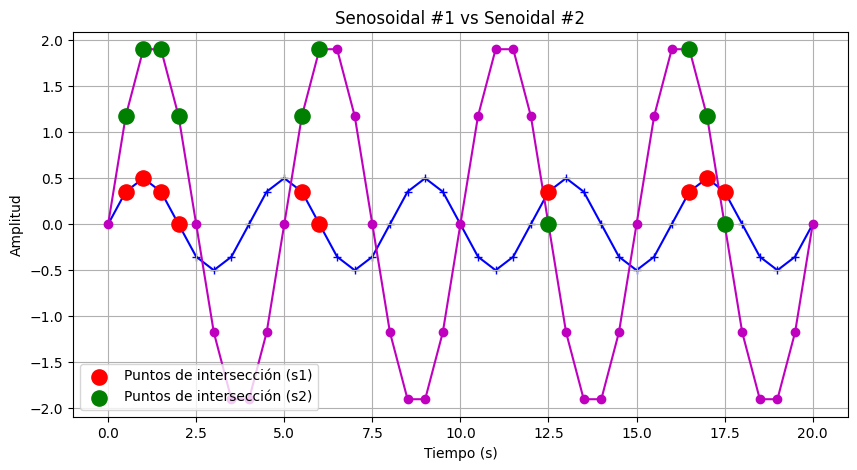

In [16]:
time=[]
time2=[]
amp=[]
amp2=[]
for i in range(len(y1)):
  if y1[i] > 0 and y2[i] > 0:
    time.append(t1[i])
    amp.append(y1[i])
    time2.append(t2[i])
    amp2.append(y2[i])
timet=np.concatenate((time,time2))
ampt=np.concatenate((amp,amp2))
print(timet)
plt.figure(figsize=(10,5))
plt.plot(t1,y1,marker="+",color="b",zorder=1)
plt.plot(t2,y2,marker="o",color="m",zorder=2)
plt.grid()
plt.legend()
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Senosoidal #1 vs Senoidal #2")
plt.legend(["Sen#1","sen#2"])
plt.scatter(time, amp, color="r", label="Puntos de intersección (s1)", s=120,zorder=3)
plt.scatter(time2, amp2, color="g", label="Puntos de intersección (s2)", s=120,zorder=4)
plt.legend()
plt.show()

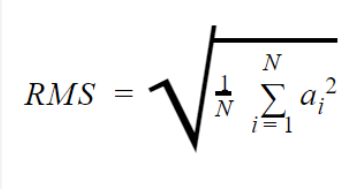

In [31]:
def rms(y1):
  rms=[]
  for i in range(len(y1)):
    rms.append(y1[i]**2)
  rms1=np.sqrt((np.sum(rms))/len(y1))
  return rms1

def graficar(t,y,rms,indi):
  plt.figure(figsize=(10,5))
  plt.plot(t,y,marker="o",color="g")
  plt.plot(t, np.ones(len(t)) * rms,linestyle="--", color="m", linewidth=1)
  plt.legend(["Senoidal","RMS"])
  plt.xlabel("Tiempo (s)")
  plt.ylabel("Amplitud")
  plt.title(f"Senosoidal {indi} vs RMS")
  plt.grid()
  plt.show()

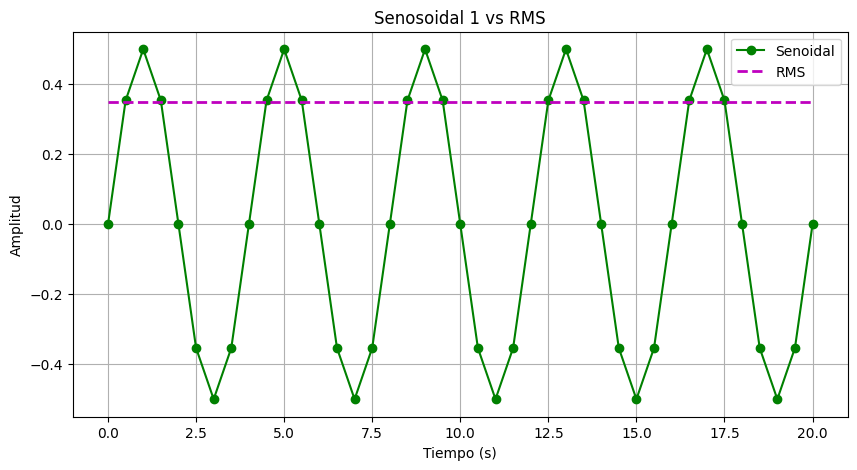

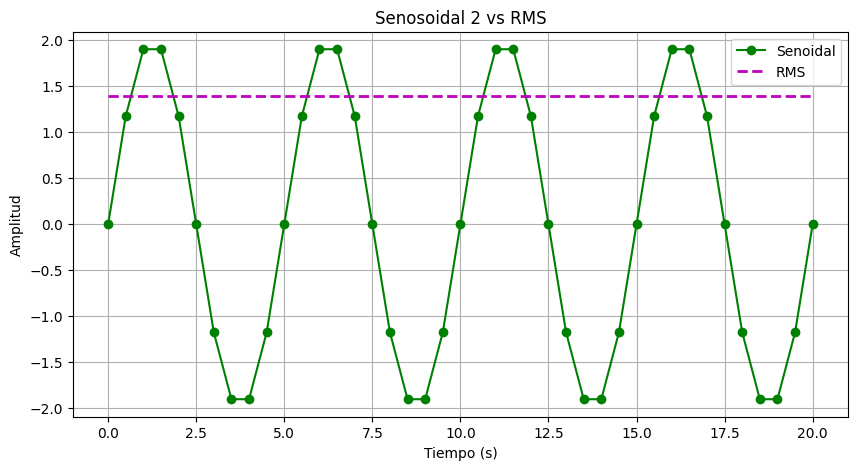

In [30]:
rms(y1)
rms(y2)
graficar(t1,y1,rms(y1),1)
graficar(t2,y2,rms(y2),2)

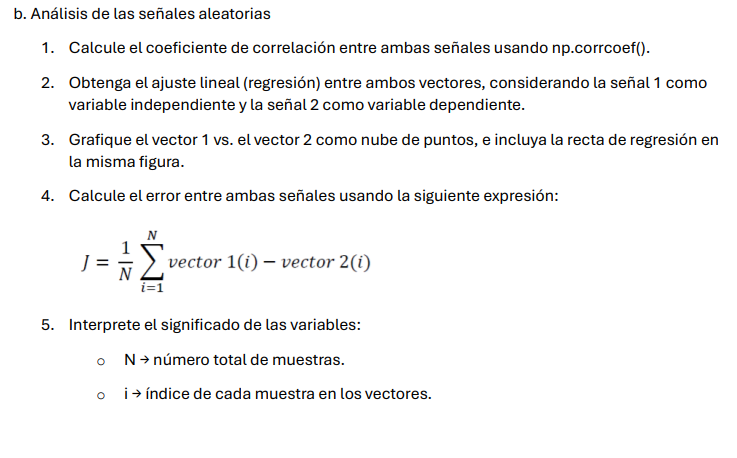

In [32]:
corr=np.corrcoef(y1,y2)
print(corr)

[[ 1.00000000e+00 -5.28160409e-17]
 [-5.28160409e-17  1.00000000e+00]]


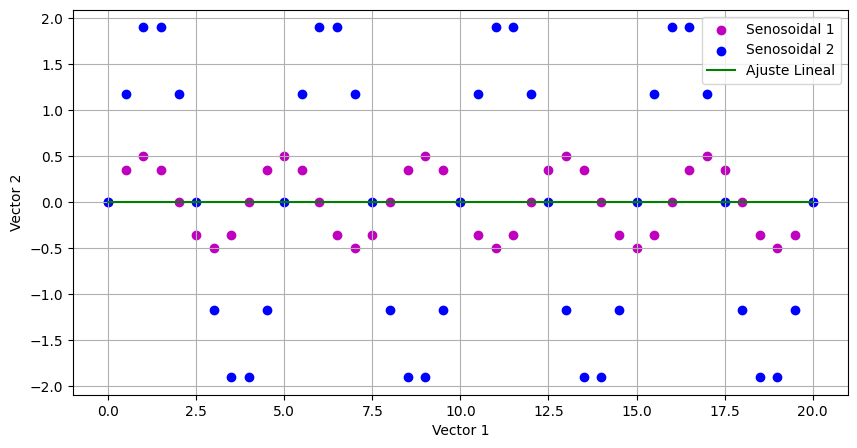

In [38]:
p1=np.polyfit(y1,y2,1)
p2=np.polyval(p1,y2)
plt.figure(figsize=(10,5))
plt.scatter(t1,y1,color="m", label="Senosoidal 1")
plt.scatter(t2,y2,color="b",label="Senosoidal 2")
plt.plot(t1,p2,"g", label="Ajuste Lineal")
plt.grid()
plt.legend()
plt.xlabel("Vector 1")
plt.ylabel("Vector 2")
plt.show()

In [41]:
vect=[]
for i in range(len(y1)):
  er=y1[i]-y2[i]
  vect.append(er)
vect=np.array(vect)
J=1/(len(y1))* np.sum(vect)
print(f"El ERROR es: {J}")

El ERROR es: 3.2856377538099724e-17
